
esm-piControl
Found 25 files
/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-piControl/latest/omz_volume_2mgL/omzvol_2mgL_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gr_185101-186012.nc
/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-piControl/latest/omz_volume_2mgL/omzvol_2mgL_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gr_209101-210012.nc

esm-up2p0
Found 23 files
/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0/v20251010/omz_volume_2mgL/omzvol_2mgL_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_185001-185912.nc
/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0/v20251010/omz_volume_2mgL/omzvol_2mgL_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_207001-207412.nc

esm-up2p0-swl2p0
Found 31 files
/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0-swl2p0/v20251009/omz_volume_2mgL/omzvol_2mgL_Omon_NorESM2-LM_esm-up2p0-swl2p0_r1i1p1f1_gr_195101-195912.nc
/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM

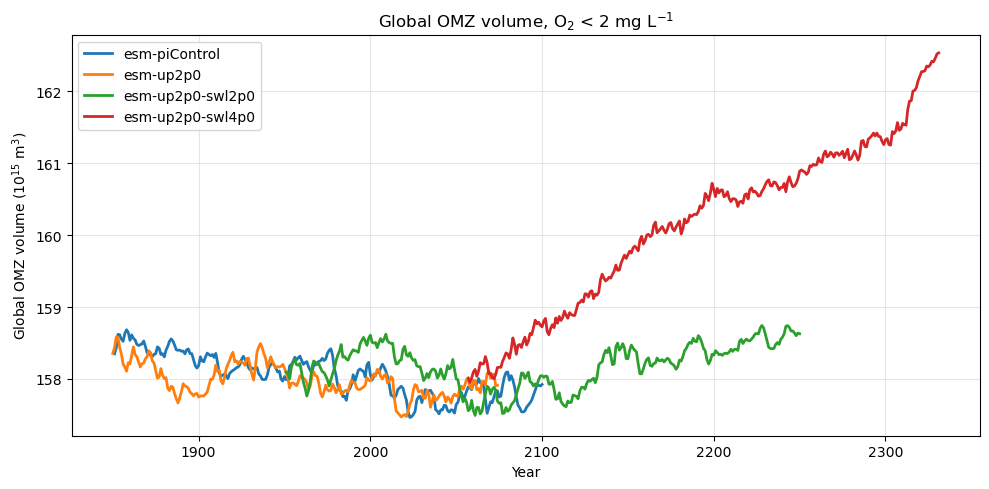

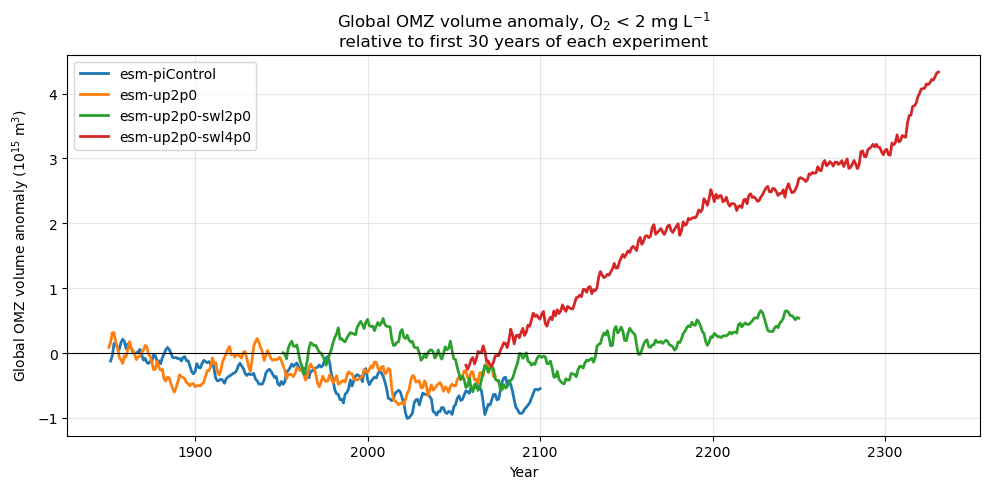

In [2]:
import xarray as xr
import numpy as np
import glob
import os
import matplotlib.pyplot as plt

# ============================================================
# Settings
# ============================================================

EXP_INFO = {
    "esm-piControl": {
        "path": "/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-piControl/latest/omz_volume_2mgL",
        "pattern": "omzvol_2mgL_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gr_*.nc",
    },
    "esm-up2p0": {
        "path": "/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0/v20251010/omz_volume_2mgL",
        "pattern": "omzvol_2mgL_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_*.nc",
    },
    "esm-up2p0-swl2p0": {
        "path": "/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0-swl2p0/v20251009/omz_volume_2mgL",
        "pattern": "omzvol_2mgL_Omon_NorESM2-LM_esm-up2p0-swl2p0_r1i1p1f1_gr_*.nc",
    },
    "esm-up2p0-swl4p0": {
        "path": "/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0-swl4p0/v20251010/omz_volume_2mgL",
        "pattern": "omzvol_2mgL_Omon_NorESM2-LM_esm-up2p0-swl4p0_r1i1p1f1_gr_*.nc",
    },
}

VAR_NAME = "omz_volume"


# ============================================================
# Function
# ============================================================

def load_global_sum_omz_volume(exp_path, pattern, var_name):
    files = sorted(glob.glob(os.path.join(exp_path, pattern)))

    if len(files) == 0:
        raise FileNotFoundError(f"No files found: {os.path.join(exp_path, pattern)}")

    print(f"Found {len(files)} files")
    print(files[0])
    print(files[-1])

    ds = xr.open_mfdataset(
        files,
        combine="by_coords",
        use_cftime=True,
        parallel=False,
    )

    omz = ds[var_name]

    # Replace only the explicit missing value with NaN, not real zeros
    fill_value = omz.attrs.get("_FillValue", None)
    if fill_value is not None:
        omz = omz.where(omz != fill_value)

    # m3 summed over horizontal grid
    omz_global = omz.sum(dim=["j", "i"], skipna=True)

    omz_global.name = "omz_volume_global_sum"
    omz_global.attrs["units"] = "m3"

    omz_ann = omz_global.groupby("time.year").mean("time")
    omz_ann.name = "omz_volume_global_sum_annual"

    ds.close()

    return omz_ann


# ============================================================
# Load all experiments
# ============================================================

omz_ann_dict = {}

for exp, info in EXP_INFO.items():
    print("\n======================================")
    print(exp)
    print("======================================")

    omz_ann_dict[exp] = load_global_sum_omz_volume(
        exp_path=info["path"],
        pattern=info["pattern"],
        var_name=VAR_NAME,
    )


# ============================================================
# Plot absolute OMZ volume
# ============================================================

plt.figure(figsize=(10, 5))

for exp, omz_ann in omz_ann_dict.items():
    plt.plot(
        omz_ann["year"],
        omz_ann / 1e15,   # m3 -> 10^15 m3
        lw=2,
        label=exp,
    )

plt.xlabel("Year")
plt.ylabel("Global OMZ volume (10$^{15}$ m$^3$)")
plt.title("Global OMZ volume, O$_2$ < 2 mg L$^{-1}$")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# Plot anomalies relative to each experiment's first 30 years
# ============================================================

plt.figure(figsize=(10, 5))

for exp, omz_ann in omz_ann_dict.items():
    years = omz_ann["year"].values
    ref_years = years[:30]

    omz_ref = omz_ann.sel(year=ref_years).mean("year")
    omz_anom = omz_ann - omz_ref

    plt.plot(
        omz_ann["year"],
        omz_anom / 1e15,
        lw=2,
        label=exp,
    )

plt.axhline(0, color="k", lw=0.8)
plt.xlabel("Year")
plt.ylabel("Global OMZ volume anomaly (10$^{15}$ m$^3$)")
plt.title("Global OMZ volume anomaly, O$_2$ < 2 mg L$^{-1}$\nrelative to first 30 years of each experiment")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


esm-piControl
Found 25 files
/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-piControl/latest/omz_volume_2mgL/omzvol_2mgL_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gr_185101-186012.nc
/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-piControl/latest/omz_volume_2mgL/omzvol_2mgL_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gr_209101-210012.nc

esm-up2p0
Found 23 files
/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0/v20251010/omz_volume_2mgL/omzvol_2mgL_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_185001-185912.nc
/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0/v20251010/omz_volume_2mgL/omzvol_2mgL_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_207001-207412.nc

esm-up2p0-swl2p0
Found 31 files
/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0-swl2p0/v20251009/omz_volume_2mgL/omzvol_2mgL_Omon_NorESM2-LM_esm-up2p0-swl2p0_r1i1p1f1_gr_195101-195912.nc
/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM

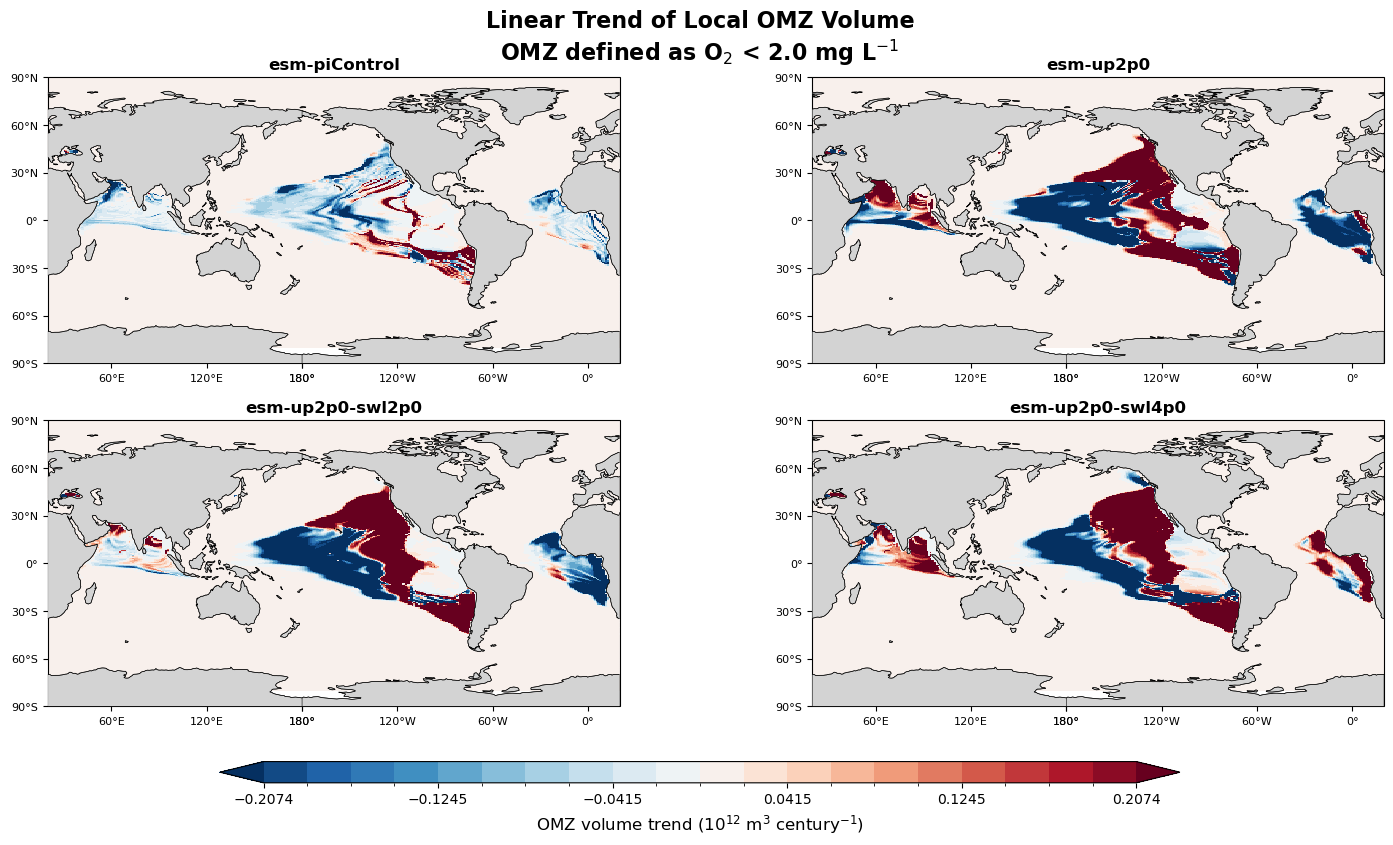

In [6]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker
import glob
import os
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", message="The colormap's 'bad' has been set")

# ============================================================
# Settings
# ============================================================

EXP_INFO = {
    "esm-piControl": {
        "path": "/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-piControl/latest/omz_volume_2mgL",
        "pattern": "omzvol_2mgL_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gr_*.nc",
        "var_name": "omz_volume",
    },
    "esm-up2p0": {
        "path": "/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0/v20251010/omz_volume_2mgL",
        "pattern": "omzvol_2mgL_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_*.nc",
        "var_name": "omz_volume",
    },
    "esm-up2p0-swl2p0": {
        "path": "/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0-swl2p0/v20251009/omz_volume_2mgL",
        "pattern": "omzvol_2mgL_Omon_NorESM2-LM_esm-up2p0-swl2p0_r1i1p1f1_gr_*.nc",
        "var_name": "omz_volume",
    },
    "esm-up2p0-swl4p0": {
        "path": "/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0-swl4p0/v20251010/omz_volume_2mgL",
        "pattern": "omzvol_2mgL_Omon_NorESM2-LM_esm-up2p0-swl4p0_r1i1p1f1_gr_*.nc",
        "var_name": "omz_volume",
    },
}


# ============================================================
# Function
# ============================================================

def compute_omz_volume_trend_map(exp_path, pattern, var_name):
    files = sorted(glob.glob(os.path.join(exp_path, pattern)))

    if len(files) == 0:
        raise FileNotFoundError(f"No files found: {os.path.join(exp_path, pattern)}")

    print(f"Found {len(files)} files")
    print(files[0])
    print(files[-1])

    ds = xr.open_mfdataset(
        files,
        combine="by_coords",
        use_cftime=True,
        data_vars="minimal",
        coords="minimal",
        compat="override",
        chunks={"time": 120},
    )

    omz = ds[var_name]

    fill_value = omz.attrs.get("_FillValue", None)
    if fill_value is not None:
        omz = omz.where(omz != fill_value)

    omz_ann = omz.groupby("time.year").mean("time")

    year = omz_ann["year"]
    x = year - year.mean()

    # Trend: m3 per century
    trend = (
        (omz_ann * x).sum("year", skipna=True)
        / (x ** 2).sum("year", skipna=True)
    ) * 100.0

    # Convert to 10^12 m3 per century
    trend = trend / 1e12

    trend.name = "omz_volume_2mgL_trend"
    trend.attrs["units"] = "10^12 m3 century-1"

    trend = trend.assign_coords(
        longitude=ds["longitude"],
        latitude=ds["latitude"],
    )

    trend = trend.compute()

    ds.close()

    return trend


# ============================================================
# Compute trend maps
# ============================================================

trend_dict = {}

for exp, info in EXP_INFO.items():
    print("\n======================================")
    print(exp)
    print("======================================")

    trend_dict[exp] = compute_omz_volume_trend_map(
        exp_path=info["path"],
        pattern=info["pattern"],
        var_name=info["var_name"],
    )




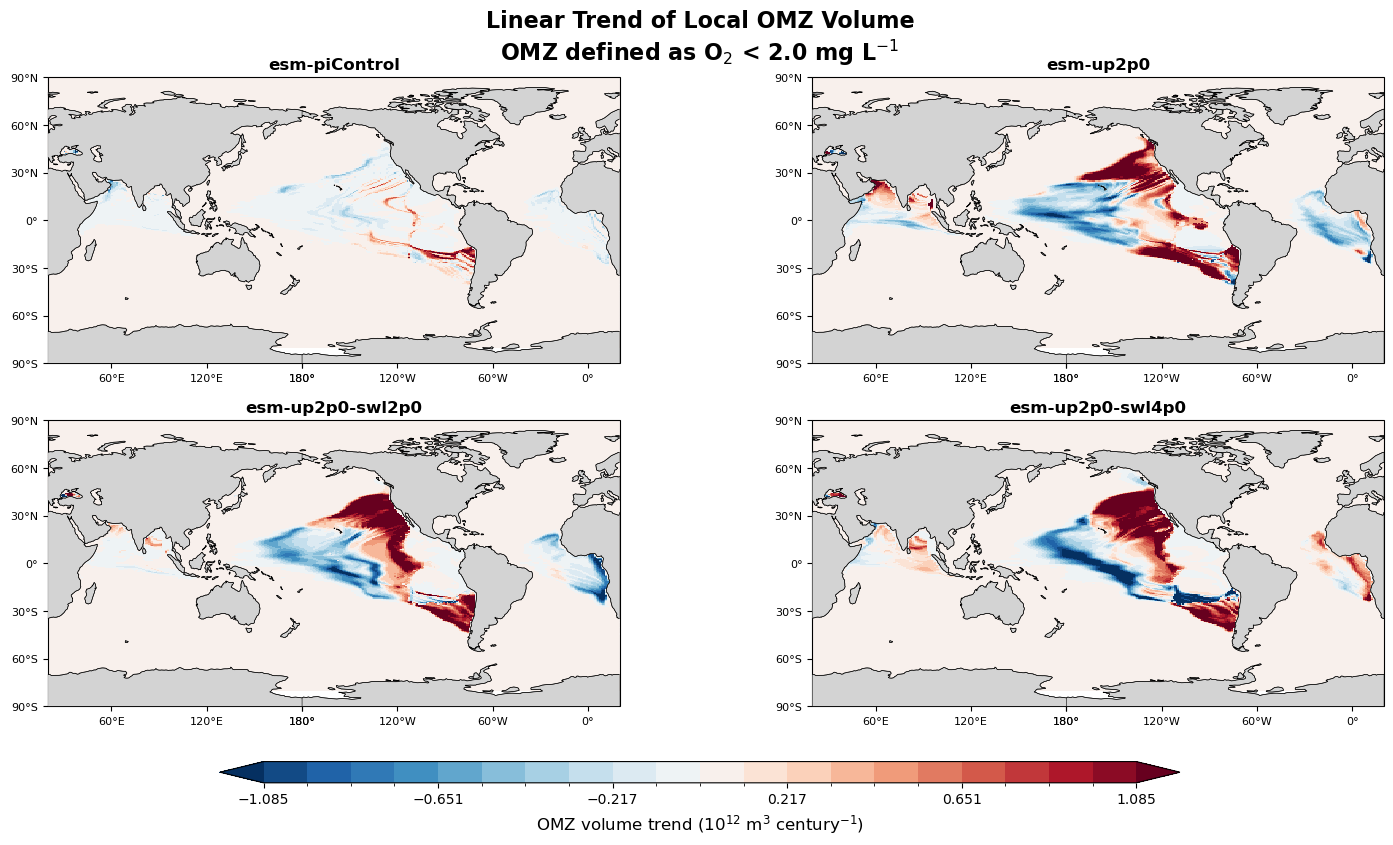

In [8]:
# ============================================================
# Plot 2 x 2 panel
# ============================================================

data_crs = ccrs.PlateCarree()
map_crs = ccrs.PlateCarree(central_longitude=200)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, 8.5),
    subplot_kw={"projection": map_crs},
)

axes = axes.flatten()

# ------------------------------------------------------------
# common color range: based only on esm-up2p0
# cover about 90% of esm-up2p0 trend magnitudes
# ------------------------------------------------------------

ref_trend = trend_dict["esm-up2p0"]

ref_values = ref_trend.values
ref_values = ref_values[np.isfinite(ref_values)]

vmax = np.nanpercentile(np.abs(ref_values), 99)
vmin = -vmax

levels = np.linspace(vmin, vmax, 21)

cmap = plt.get_cmap("RdBu_r", len(levels) + 1).copy()
cmap.set_bad(alpha=0)

norm = mcolors.BoundaryNorm(
    levels,
    cmap.N,
    extend="both"
)

# ------------------------------------------------------------
# draw maps
# ------------------------------------------------------------

for ax, (exp, trend) in zip(axes, trend_dict.items()):

    pcm = ax.pcolormesh(
        trend["longitude"],
        trend["latitude"],
        trend,
        transform=data_crs,
        cmap=cmap,
        norm=norm,
        shading="auto",
    )

    ax.add_feature(
        cfeature.LAND,
        facecolor="lightgray",
        edgecolor="black",
        linewidth=0.3,
        zorder=10,
    )

    ax.coastlines(
        resolution="110m",
        linewidth=0.5,
        zorder=11,
    )

    ax.set_global()

    ax.set_xticks(np.arange(-180, 181, 60), crs=data_crs)
    ax.set_yticks(np.arange(-90, 91, 30), crs=data_crs)

    ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
    ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())

    ax.tick_params(labelsize=8)

    ax.set_title(
        exp,
        fontsize=12,
        fontweight="bold",
    )

# ------------------------------------------------------------
# layout first, then add colorbar outside
# ------------------------------------------------------------

fig.subplots_adjust(
    left=0.05,
    right=0.97,
    top=0.90,
    bottom=0.16,
    wspace=0.08,
    hspace=0.20,
)

cbar_ax = fig.add_axes([0.20, 0.07, 0.60, 0.025])

cbar = fig.colorbar(
    pcm,
    cax=cbar_ax,
    orientation="horizontal",
    boundaries=levels,
    ticks=levels[::4],
    spacing="proportional",
    extend="both",
)

cbar.set_label(
    "OMZ volume trend ($10^{12}$ m$^3$ century$^{-1}$)",
    fontsize=12,
)

fig.suptitle(
    "Linear Trend of Local OMZ Volume\n"
    "OMZ defined as O$_2$ < 2.0 mg L$^{-1}$",
    fontsize=16,
    fontweight="bold",
)

plt.show()


esm-piControl
Found 25 files
/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-piControl/latest/lowO2_volume_4p6mgL/lowO2_volume_4p6mgL_NorESM2-LM_esm-piControl_r1i1p1f1_gr_185101-186012.nc
/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-piControl/latest/lowO2_volume_4p6mgL/lowO2_volume_4p6mgL_NorESM2-LM_esm-piControl_r1i1p1f1_gr_209101-210012.nc

esm-up2p0
Found 23 files
/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0/v20251010/lowO2_volume_4p6mgL/lowO2vol_4p6mgL_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_185001-185912.nc
/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0/v20251010/lowO2_volume_4p6mgL/lowO2vol_4p6mgL_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_207001-207412.nc

esm-up2p0-swl2p0
Found 31 files
/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0-swl2p0/v20251009/lowO2_volume_4p6mgL/lowO2_volume_4p6mgL_NorESM2-LM_esm-up2p0-swl2p0_r1i1p1f1_gr_195101-195912.nc
/nird/datalake/NS298

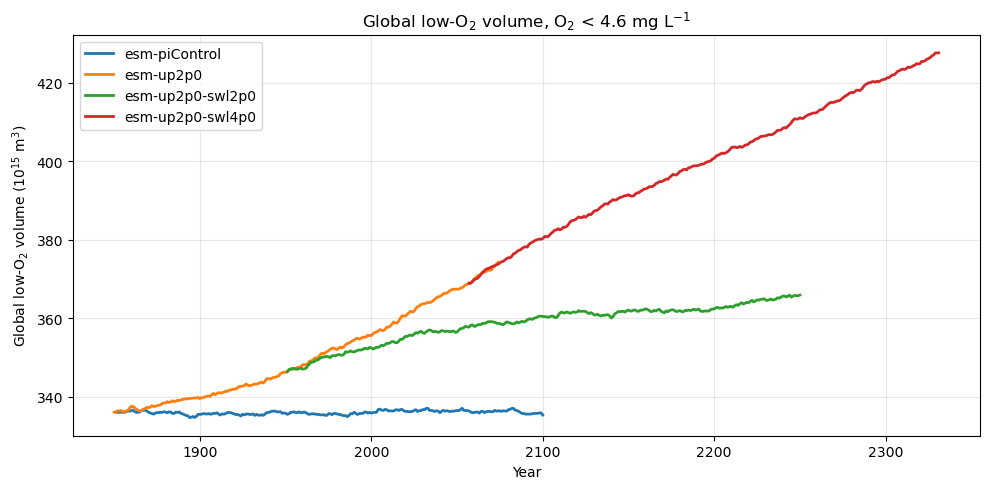

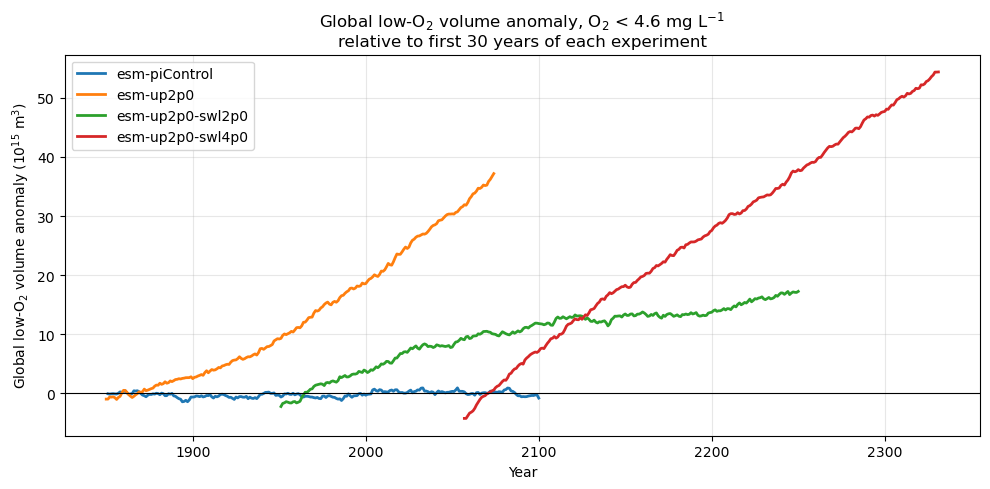

In [5]:
import xarray as xr
import glob
import os
import matplotlib.pyplot as plt

# ============================================================
# Settings
# ============================================================

EXP_INFO = {
    "esm-piControl": {
        "path": "/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-piControl/latest/lowO2_volume_4p6mgL",
        "pattern": "lowO2_volume_4p6mgL_NorESM2-LM_esm-piControl_r1i1p1f1_gr_*.nc",
        "var_name": "omz_volume",
    },
    "esm-up2p0": {
        "path": "/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0/v20251010/lowO2_volume_4p6mgL",
        "pattern": "lowO2vol_4p6mgL_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_*.nc",
        "var_name": "low_o2_volume",
    },
    "esm-up2p0-swl2p0": {
        "path": "/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0-swl2p0/v20251009/lowO2_volume_4p6mgL",
        "pattern": "lowO2_volume_4p6mgL_NorESM2-LM_esm-up2p0-swl2p0_r1i1p1f1_gr_*.nc",
        "var_name": "omz_volume",
    },
    "esm-up2p0-swl4p0": {
        "path": "/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0-swl4p0/v20251010/lowO2_volume_4p6mgL",
        "pattern": "lowO2_volume_4p6mgL_NorESM2-LM_esm-up2p0-swl4p0_r1i1p1f1_gr_*.nc",
        "var_name": "omz_volume",
    },
}


# ============================================================
# Function
# ============================================================

def load_global_sum_lowO2_volume(exp_path, pattern, var_name):
    files = sorted(glob.glob(os.path.join(exp_path, pattern)))

    if len(files) == 0:
        raise FileNotFoundError(f"No files found: {os.path.join(exp_path, pattern)}")

    print(f"Found {len(files)} files")
    print(files[0])
    print(files[-1])

    ds = xr.open_mfdataset(
        files,
        combine="by_coords",
        use_cftime=True,
        parallel=False,
    )

    vol = ds[var_name]

    fill_value = vol.attrs.get("_FillValue", None)
    if fill_value is not None:
        vol = vol.where(vol != fill_value)

    # Variable is already volume per horizontal grid cell [m3].
    # Do not multiply by areacello.
    vol_global = vol.sum(dim=["j", "i"], skipna=True)

    vol_global.name = "lowO2_4p6mgL_volume_global_sum"
    vol_global.attrs["units"] = "m3"

    vol_ann = vol_global.groupby("time.year").mean("time")
    vol_ann.name = "lowO2_4p6mgL_volume_global_sum_annual"

    ds.close()

    return vol_ann


# ============================================================
# Load all experiments
# ============================================================

lowo2_4p6_ann_dict = {}

for exp, info in EXP_INFO.items():
    print("\n======================================")
    print(exp)
    print("======================================")

    lowo2_4p6_ann_dict[exp] = load_global_sum_lowO2_volume(
        exp_path=info["path"],
        pattern=info["pattern"],
        var_name=info["var_name"],
    )


# ============================================================
# Plot absolute low-O2 volume
# ============================================================

plt.figure(figsize=(10, 5))

for exp, vol_ann in lowo2_4p6_ann_dict.items():
    plt.plot(
        vol_ann["year"],
        vol_ann / 1e15,
        lw=2,
        label=exp,
    )

plt.xlabel("Year")
plt.ylabel("Global low-O$_2$ volume (10$^{15}$ m$^3$)")
plt.title("Global low-O$_2$ volume, O$_2$ < 4.6 mg L$^{-1}$")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# Plot anomalies relative to each experiment's first 30 years
# ============================================================

plt.figure(figsize=(10, 5))

for exp, vol_ann in lowo2_4p6_ann_dict.items():
    years = vol_ann["year"].values
    ref_years = years[:30]

    vol_ref = vol_ann.sel(year=ref_years).mean("year")
    vol_anom = vol_ann - vol_ref

    plt.plot(
        vol_ann["year"],
        vol_anom / 1e15,
        lw=2,
        label=exp,
    )

plt.axhline(0, color="k", lw=0.8)
plt.xlabel("Year")
plt.ylabel("Global low-O$_2$ volume anomaly (10$^{15}$ m$^3$)")
plt.title(
    "Global low-O$_2$ volume anomaly, O$_2$ < 4.6 mg L$^{-1}$\n"
    "relative to first 30 years of each experiment"
)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


esm-piControl
Found 25 files
/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-piControl/latest/lowO2_volume_4p6mgL/lowO2_volume_4p6mgL_NorESM2-LM_esm-piControl_r1i1p1f1_gr_185101-186012.nc
/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-piControl/latest/lowO2_volume_4p6mgL/lowO2_volume_4p6mgL_NorESM2-LM_esm-piControl_r1i1p1f1_gr_209101-210012.nc

esm-up2p0
Found 23 files
/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0/v20251010/lowO2_volume_4p6mgL/lowO2vol_4p6mgL_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_185001-185912.nc
/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0/v20251010/lowO2_volume_4p6mgL/lowO2vol_4p6mgL_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_207001-207412.nc

esm-up2p0-swl2p0
Found 31 files
/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0-swl2p0/v20251009/lowO2_volume_4p6mgL/lowO2_volume_4p6mgL_NorESM2-LM_esm-up2p0-swl2p0_r1i1p1f1_gr_195101-195912.nc
/nird/datalake/NS298

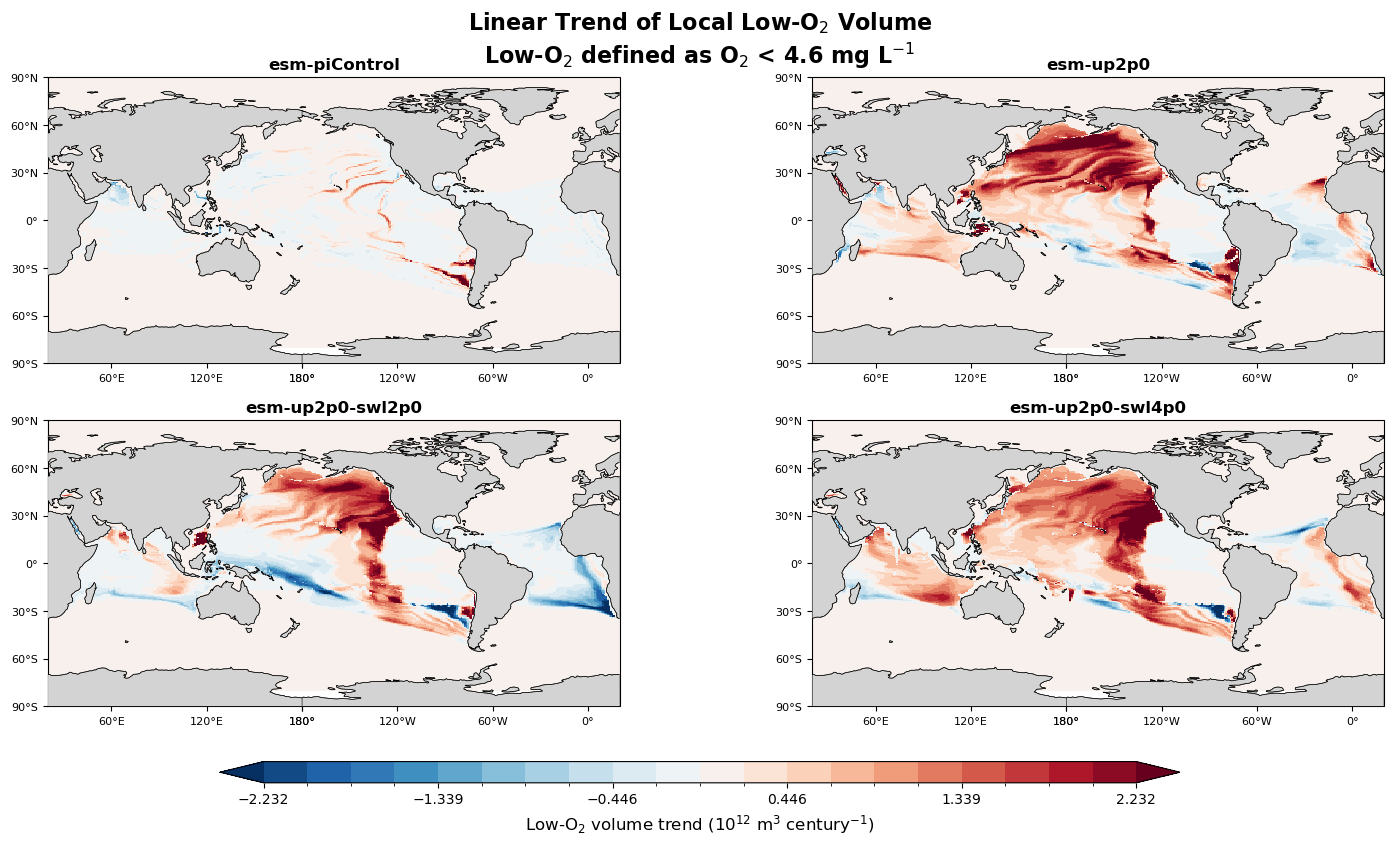

In [9]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker
import glob
import os
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", message="The colormap's 'bad' has been set")

# ============================================================
# Settings
# ============================================================

EXP_INFO = {
    "esm-piControl": {
        "path": "/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-piControl/latest/lowO2_volume_4p6mgL",
        "pattern": "lowO2_volume_4p6mgL_NorESM2-LM_esm-piControl_r1i1p1f1_gr_*.nc",
        "var_name": "omz_volume",
    },
    "esm-up2p0": {
        "path": "/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0/v20251010/lowO2_volume_4p6mgL",
        "pattern": "lowO2vol_4p6mgL_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_*.nc",
        "var_name": "low_o2_volume",
    },
    "esm-up2p0-swl2p0": {
        "path": "/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0-swl2p0/v20251009/lowO2_volume_4p6mgL",
        "pattern": "lowO2_volume_4p6mgL_NorESM2-LM_esm-up2p0-swl2p0_r1i1p1f1_gr_*.nc",
        "var_name": "omz_volume",
    },
    "esm-up2p0-swl4p0": {
        "path": "/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0-swl4p0/v20251010/lowO2_volume_4p6mgL",
        "pattern": "lowO2_volume_4p6mgL_NorESM2-LM_esm-up2p0-swl4p0_r1i1p1f1_gr_*.nc",
        "var_name": "omz_volume",
    },
}


# ============================================================
# Function
# ============================================================

def compute_lowo2_4p6_volume_trend_map(exp_path, pattern, var_name):
    files = sorted(glob.glob(os.path.join(exp_path, pattern)))

    if len(files) == 0:
        raise FileNotFoundError(f"No files found: {os.path.join(exp_path, pattern)}")

    print(f"Found {len(files)} files")
    print(files[0])
    print(files[-1])

    ds = xr.open_mfdataset(
        files,
        combine="by_coords",
        use_cftime=True,
        data_vars="minimal",
        coords="minimal",
        compat="override",
        chunks={"time": 120},
    )

    vol = ds[var_name]

    fill_value = vol.attrs.get("_FillValue", None)
    if fill_value is not None:
        vol = vol.where(vol != fill_value)

    vol_ann = vol.groupby("time.year").mean("time")

    year = vol_ann["year"]
    x = year - year.mean()

    # Trend: m3 per century
    trend = (
        (vol_ann * x).sum("year", skipna=True)
        / (x ** 2).sum("year", skipna=True)
    ) * 100.0

    # Convert to 10^12 m3 per century
    trend = trend / 1e12

    trend.name = "lowO2_4p6mgL_volume_trend"
    trend.attrs["units"] = "10^12 m3 century-1"

    trend = trend.assign_coords(
        longitude=ds["longitude"],
        latitude=ds["latitude"],
    )

    trend = trend.compute()

    ds.close()

    return trend


# ============================================================
# Compute trend maps
# ============================================================

trend_dict = {}

for exp, info in EXP_INFO.items():
    print("\n======================================")
    print(exp)
    print("======================================")

    trend_dict[exp] = compute_lowo2_4p6_volume_trend_map(
        exp_path=info["path"],
        pattern=info["pattern"],
        var_name=info["var_name"],
    )


# ============================================================
# Plot 2 x 2 panel
# ============================================================

data_crs = ccrs.PlateCarree()
map_crs = ccrs.PlateCarree(central_longitude=200)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, 8.5),
    subplot_kw={"projection": map_crs},
)

axes = axes.flatten()

# Color range based only on esm-up2p0, covering about 99%
ref_trend = trend_dict["esm-up2p0"]

ref_values = ref_trend.values
ref_values = ref_values[np.isfinite(ref_values)]

vmax = np.nanpercentile(np.abs(ref_values), 99)
vmin = -vmax

levels = np.linspace(vmin, vmax, 21)

cmap = plt.get_cmap("RdBu_r", len(levels) + 1).copy()
cmap.set_bad(alpha=0)

norm = mcolors.BoundaryNorm(
    levels,
    cmap.N,
    extend="both"
)

# Draw maps
for ax, (exp, trend) in zip(axes, trend_dict.items()):

    pcm = ax.pcolormesh(
        trend["longitude"],
        trend["latitude"],
        trend,
        transform=data_crs,
        cmap=cmap,
        norm=norm,
        shading="auto",
    )

    ax.add_feature(
        cfeature.LAND,
        facecolor="lightgray",
        edgecolor="black",
        linewidth=0.3,
        zorder=10,
    )

    ax.coastlines(
        resolution="110m",
        linewidth=0.5,
        zorder=11,
    )

    ax.set_global()

    ax.set_xticks(np.arange(-180, 181, 60), crs=data_crs)
    ax.set_yticks(np.arange(-90, 91, 30), crs=data_crs)

    ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
    ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())

    ax.tick_params(labelsize=8)

    ax.set_title(
        exp,
        fontsize=12,
        fontweight="bold",
    )

# Layout and colorbar outside
fig.subplots_adjust(
    left=0.05,
    right=0.97,
    top=0.90,
    bottom=0.16,
    wspace=0.08,
    hspace=0.20,
)

cbar_ax = fig.add_axes([0.20, 0.07, 0.60, 0.025])

cbar = fig.colorbar(
    pcm,
    cax=cbar_ax,
    orientation="horizontal",
    boundaries=levels,
    ticks=levels[::4],
    spacing="proportional",
    extend="both",
)

cbar.set_label(
    "Low-O$_2$ volume trend ($10^{12}$ m$^3$ century$^{-1}$)",
    fontsize=12,
)

fig.suptitle(
    "Linear Trend of Local Low-O$_2$ Volume\n"
    "Low-O$_2$ defined as O$_2$ < 4.6 mg L$^{-1}$",
    fontsize=16,
    fontweight="bold",
)

plt.show()